# Bayesian Inversion with torchTT

First we define a random process with memory governed by a **Stochastic Integro-Differential Equation (SIDE)**.
The process incorporates an integral term with an exponential memory kernel:
$$ dX_t = \left(\alpha X_t + \beta \int_0^t e^{-\kappa(t-s)} X_s \, ds + \gamma \right) dt + \sigma dW_t $$
where $W_t$ is a standard Brownian motion and $\kappa > 0$ controls the decay rate of the memory kernel.

By introducing an auxiliary variable $I_t = \int_0^t e^{-\kappa(t-s)} X_s \, ds$, we note that $I_t$ satisfies:
$$ dI_t = (X_t - \kappa I_t) \, dt $$

Discretizing using the Euler-Maruyama method gives:
$$ X_{i} = X_{i-1} + (\alpha X_{i-1} + \beta I_{i-1} + \gamma)\Delta t + \sigma \sqrt{\Delta t} Z_i $$
$$ I_{i} = I_{i-1} + (X_{i-1} - \kappa I_{i-1})\Delta t $$
with $Z_i \sim \mathcal{N}(0, 1)$.

In [7]:
import math 
import torch
import matplotlib.pyplot as plt
import numpy as np
import torchtt 
import torchtt.functional 
import time

torch.set_default_dtype(torch.float64)
torch.manual_seed(1234)
np.random.seed(1234)

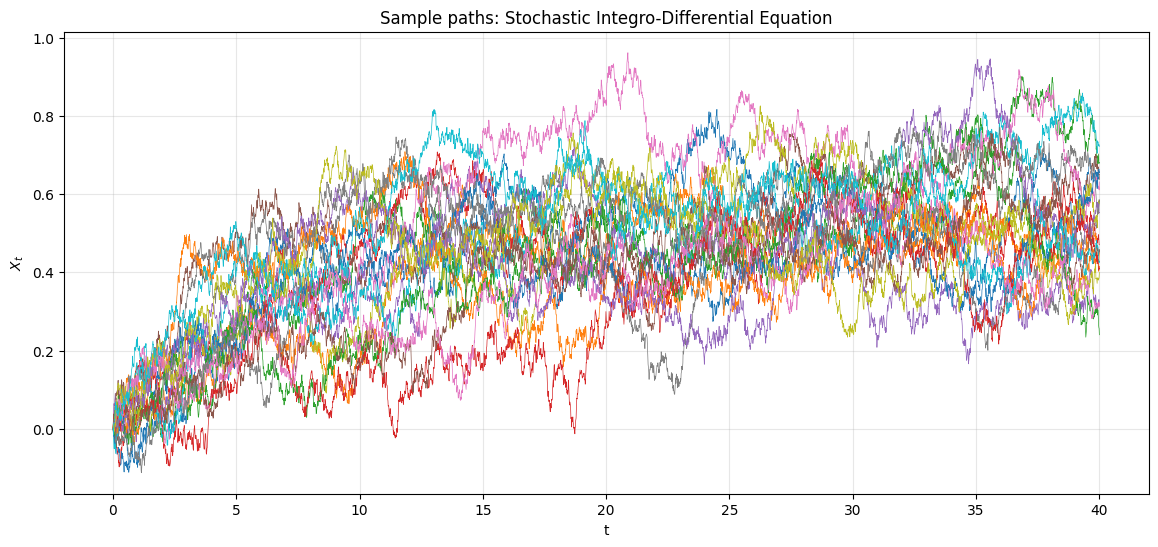

In [8]:
def sample_integro_process(ns, nt, dt, params):
    """
    Sample paths of a Stochastic Integro-Differential Equation (SIDE).
    
    dX_t = (alpha * X_t + beta * I_t + gamma) dt + sigma dW_t
    dI_t = (X_t - kappa * I_t) dt
    
    where I_t = integral_0^t exp(-kappa*(t-s)) X_s ds
    
    Parameters:
      ns    : number of sample paths
      nt    : number of time steps
      dt    : time step size
      params: [alpha, beta, gamma, kappa, sigma]
    
    Returns:
      X: tensor of shape (ns, nt+1) with sample paths
      t_grid: tensor of shape (nt+1,) with time values
    """
    alpha, beta, gamma, kappa, sigma = params
    
    X = torch.zeros(ns, nt + 1)
    I = torch.zeros(ns)  # integral state, starts at 0
    
    sqrt_dt = math.sqrt(dt)
    
    for i in range(1, nt + 1):
        dW = torch.randn(ns) * sqrt_dt
        X_prev = X[:, i - 1]
        
        # Update X
        X[:, i] = X_prev + (alpha * X_prev + beta * I + gamma) * dt + sigma * dW
        
        # Update the integral state I
        I = I + (X_prev - kappa * I) * dt
    
    t_grid = torch.arange(0, nt + 1) * dt
    return X, t_grid


# Parameters: [alpha, beta, gamma, kappa, sigma]
params = [-0.5, 0.3, 0.1, 1.0, 0.1]

ns = 20     # number of sample paths
T = 40.0     # total time
dt = 0.01   # time step
nt = int(T / dt)

X, t_grid = sample_integro_process(ns, nt, dt, params)

plt.figure(figsize=(14, 6))
for k in range(ns):
    plt.plot(t_grid.numpy(), X[k, :].numpy(), linewidth=0.5)
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.title('Sample paths: Stochastic Integro-Differential Equation')
plt.grid(True, alpha=0.3)
plt.show()


## Log-likelihood for the SIDE

Given a path $X$ and the discretization:
$$ X_{i} = X_{i-1} + (\alpha X_{i-1} + \beta I_{i-1} + \gamma)\Delta t + \sigma \sqrt{\Delta t} Z_i, $$

the transition density is Gaussian:
$$ X_i \mid X_{i-1}, I_{i-1} \sim \mathcal{N}\!\left(X_{i-1} + (\alpha X_{i-1} + \beta I_{i-1} + \gamma)\Delta t,\; \sigma^2 \Delta t\right). $$

The likelihood of an observed path $Y = (Y_0,\dots,Y_N)$ given $\theta = (\alpha,\beta,\gamma,\kappa,\sigma)$ is the product of these transition densities,
$$
L(\theta) \;:=\; L(Y \mid \theta) \;=\; \prod_{i=1}^{N} p(Y_i \mid Y_{i-1}, I_{i-1};\,\theta),
$$
and the corresponding log-likelihood
$$
\ell(\theta) \;=\; \log L(\theta) \;=\; \sum_{i=1}^{N} \log p(Y_i \mid Y_{i-1}, I_{i-1};\,\theta)
$$
is summed over all time steps. Note that the integral state $I_i$ must be reconstructed from the observed path for each parameter evaluation.

In [9]:

def process_log_likelihood(Y, dt, params, start_idx=1, end_idx=None):
    """
    Compute the log-likelihood of a single observed path Y under the SIDE model.
    
    Parameters:
      Y        : 1D tensor of shape (nt+1,) — one observed path
      dt       : scalar time step
      params   : [alpha, beta, gamma, kappa, sigma]
                 Each can be a scalar or a 1D tensor of shape (np,) for vectorized evaluation.
      start_idx: first time index to include in the likelihood
      end_idx  : last time index (exclusive); defaults to len(Y)
    
    Returns:
      log_lik  : scalar or tensor of shape (np,)
    """
    alpha, beta, gamma, kappa, sigma = params
    
    if end_idx is None:
        end_idx = len(Y)
    
    if isinstance(alpha, torch.Tensor) and alpha.dim() > 0:
        # Vectorized over parameter grid: alpha, beta, gamma, kappa, sigma all (np,)
        np_size = alpha.shape[0]
        
        var = (sigma ** 2) * dt  # (np,)
        norm_term = -0.5 * torch.log(2 * math.pi * var)  # (np,)
        
        # Reconstruct the integral state I for each parameter vector
        # I has shape (np,) and evolves over time
        I_state = torch.zeros(np_size, dtype=Y.dtype, device=Y.device)  # (np,)
        
        # First, evolve I from 0 to start_idx (no likelihood contribution)
        for i in range(1, start_idx):
            I_state = I_state + (Y[i-1] - kappa * I_state) * dt
        
        # Now compute log-likelihood from start_idx to end_idx
        log_lik = torch.zeros(np_size, dtype=Y.dtype, device=Y.device)
        
        for i in range(start_idx, end_idx):
            mu = Y[i-1] + (alpha * Y[i-1] + beta * I_state + gamma) * dt  # (np,)
            residuals = Y[i] - mu  # (np,)
            log_lik = log_lik + norm_term - 0.5 * (residuals ** 2) / var
            
            # Update integral state
            I_state = I_state + (Y[i-1] - kappa * I_state) * dt
        
        return log_lik
    
    else:
        # Scalar parameters
        var = (sigma ** 2) * dt
        norm_term = -0.5 * math.log(2 * math.pi * var)
        
        I_state = 0.0
        
        # Evolve I from 0 to start_idx
        for i in range(1, start_idx):
            I_state = I_state + (Y[i-1].item() - kappa * I_state) * dt
        
        log_lik = 0.0
        
        for i in range(start_idx, end_idx):
            mu = Y[i-1] + (alpha * Y[i-1] + beta * I_state + gamma) * dt
            residual = Y[i] - mu
            log_lik = log_lik + norm_term - 0.5 * (residual ** 2) / var
            
            I_state = I_state + (Y[i-1].item() - kappa * I_state) * dt
        
        return log_lik


# Example usage: Evaluate the likelihood of a single path using true parameters
log_lik_scalar = process_log_likelihood(X[0, :], dt, params, start_idx=1)
print("Scalar log-likelihood:", log_lik_scalar)

# Example usage: Vectorized evaluation
np_evals = 10
vec_params = [torch.full((np_evals,), p, dtype=torch.float64) for p in params]
log_lik_vec = process_log_likelihood(X[0, :], dt, vec_params, start_idx=1)
print("Vectorized log-likelihood:", log_lik_vec)


Scalar log-likelihood: tensor(12652.0511)
Vectorized log-likelihood: tensor([12652.0511, 12652.0511, 12652.0511, 12652.0511, 12652.0511, 12652.0511,
        12652.0511, 12652.0511, 12652.0511, 12652.0511])


## Tensor product basis representation

Let $\theta = (\theta_1,\dots,\theta_d) = (\alpha,\beta,\gamma,\kappa,\sigma) \in \Omega = \prod_{k=1}^d \Omega_k \subset \mathbb{R}^d$, with $d=5$. For each coordinate $k$ we choose a univariate B-spline basis $\{\varphi_{k,i_k}\}_{i_k=1}^{n_k}$ on $\Omega_k$ and form the tensor product basis
$$
\Phi_{i_1\cdots i_d}(\theta) \;=\; \prod_{k=1}^{d} \varphi_{k,i_k}(\theta_k).
$$
Any function $f:\Omega \to \mathbb{R}$ is represented through its coefficient tensor $\mathsf{F} \in \mathbb{R}^{n_1\times\cdots\times n_d}$ as
$$
f(\theta) \;\approx\; \sum_{i_1,\dots,i_d} \mathsf{F}_{i_1\cdots i_d}\, \Phi_{i_1\cdots i_d}(\theta).
$$

Collocation at interpolation nodes $\{x_{k,j_k}\}_{j_k=1}^{n_k}$ defines univariate matrices $B_k \in \mathbb{R}^{n_k\times n_k}$ with $(B_k)_{j_k i_k} = \varphi_{k,i_k}(x_{k,j_k})$. Values on the tensor grid are then linked to coefficients through the rank-one Kronecker operator
$$
B \;=\; B_1 \otimes \cdots \otimes B_d, \qquad \mathsf{F}^{\text{vals}} \;=\; B\,\mathsf{F}.
$$

Integration is performed with separable quadrature weights $w_k \in \mathbb{R}^{n_k}$,
$$
\int_\Omega f(\theta)\,d\theta \;\approx\; \sum_{j_1,\dots,j_d} \mathsf{F}^{\text{vals}}_{j_1\cdots j_d} \prod_{k=1}^d w_{k,j_k},
$$
which is itself a rank-one tensor contraction.

The prior is chosen separable,
$$
\pi_0(\theta) \;=\; \frac{1}{Z_0}\prod_{k=1}^d \pi_{0,k}(\theta_k),
$$
so its coefficient tensor has TT-rank one. Concretely we use Gaussian factors for $\alpha,\beta,\gamma$ and log-normal factors for the positive parameters $\kappa,\sigma$, and normalize so that $\int_\Omega \pi_0(\theta)\,d\theta = 1$.

Posterior summaries are computed by quadrature against the same weights:
$$
\mathbb{E}[\theta_k] \;=\; \int_\Omega \theta_k\, \pi(\theta)\,d\theta,
\qquad
\operatorname{Cov}(\theta_k,\theta_\ell) \;=\; \mathbb{E}[\theta_k\theta_\ell] - \mathbb{E}[\theta_k]\,\mathbb{E}[\theta_\ell].
$$

In [10]:
# Number of quadrature points
n = 32
bases = [
    torchtt.functional.BSplineBasis(torch.linspace(-1.5, 0.5, n-1), 2),
    torchtt.functional.BSplineBasis(torch.linspace(-0.2, 0.8, n-1), 2),
    torchtt.functional.BSplineBasis(torch.linspace(-0.5, 0.7, n-1), 2),
    torchtt.functional.BSplineBasis(torch.linspace(0.3, 2.0, n-1), 2),
    torchtt.functional.BSplineBasis(torch.linspace(0.03, 0.2, n-1), 2)
]
interpolation_pts = [b.interpolating_points()[0] for b in bases] 
interpolation_matrices = [b.interpolating_points()[1] for b in bases]
B_eval = torchtt.rank1TT(interpolation_matrices)
B_eval_inv = torchtt.rank1TT([torch.linalg.inv(m) for m in interpolation_matrices])
integration_weights = [b.integration_weights() for b in bases]
Ws = torchtt.rank1TT(integration_weights)

gauss_unnorm = lambda x, mu, std: torch.exp(-0.5*(x-mu)**2/std**2)
prior = torchtt.rank1TT([
    gauss_unnorm(interpolation_pts[0], -0.4, 0.3),
    gauss_unnorm(interpolation_pts[1], 0.35, 0.15),
    gauss_unnorm(interpolation_pts[2], 0.0, 0.2),
    gauss_unnorm(torch.log(interpolation_pts[3]), np.log(1.2), 0.3) / interpolation_pts[3],
    gauss_unnorm(torch.log(interpolation_pts[4]), np.log(0.08), 0.3) / interpolation_pts[4],
])
prior = prior / torchtt.dot(B_eval_inv @ prior, Ws)


def statistics(prob, xs, Ws):
    n_params = len(xs)
    Es = torch.zeros(n_params)
    Cs = torch.zeros((n_params, n_params))
    
    Xs = torchtt.meshgrid(xs)
    
    for i in range(n_params):
        Es[i] = float(torchtt.dot(prob, Xs[i] * Ws))
        
    for i in range(n_params):
        for j in range(i, n_params):
            E_xixj = float(torchtt.dot(prob, Xs[i] * Xs[j] * Ws))
            cov = E_xixj - Es[i] * Es[j]
            Cs[i, j] = cov
            Cs[j, i] = cov
            
    return Es, Cs

print("Joint prior TT shape:", prior.N)
Es, Cs = statistics(prior, interpolation_pts, Ws)
print("Expectations: ", Es)
print("Covariance Matrix: \n", Cs)


Joint prior TT shape: [32, 32, 32, 32, 32]
Expectations:  tensor([-0.4008,  0.3490,  0.0034,  1.2063,  0.0835])
Covariance Matrix: 
 tensor([[ 8.8666e-02, -1.6900e-04, -1.6659e-06, -5.8422e-04, -4.0429e-05],
        [-1.6900e-04,  2.2265e-02,  1.4505e-06,  5.0869e-04,  3.5202e-05],
        [-1.6659e-06,  1.4505e-06,  3.8018e-02,  5.0146e-06,  3.4701e-07],
        [-5.8422e-04,  5.0869e-04,  5.0146e-06,  1.0287e-01,  1.2169e-04],
        [-4.0429e-05,  3.5202e-05,  3.4701e-07,  1.2169e-04,  6.4483e-04]])


## Bayesian inference

Given the observed path $Y$ and the likelihood $L(\theta)$ defined above, Bayes' rule reads
$$
\pi(\theta \mid Y) \;\propto\; \pi_0(\theta)\, L(\theta).
$$

We split the observation window into disjoint blocks indexed by $k$ and factor the likelihood as
$L(\theta) = \prod_k L_k(\theta)$, so that Bayes' rule can be applied sequentially:
$$
\pi_{k+1}(\theta) \;\propto\; \pi_k(\theta)\, L_k(\theta), \qquad \pi_0 = \text{prior}.
$$
For numerical stability we work in log-space and subtract a constant shift $c_k = \log L_k(\theta_\star)$ at a reference point $\theta_\star$, which does not change the normalized posterior:
$$
\pi_{k+1}(\theta) \;\propto\; \pi_k(\theta)\, \exp\!\bigl(\log L_k(\theta) - c_k\bigr).
$$

At each step the new posterior, viewed as a tensor on the parameter grid, is approximated in TT format by adaptive cross interpolation (AMEN),
$$
\pi_{k+1} \;\approx\; \mathrm{TT}\!\left[\,(\theta,\, \pi_k(\theta)) \;\mapsto\; \pi_k(\theta)\,e^{\log L_k(\theta) - c_k}\,\right],
$$
using $\pi_k$ as a warm start. The result is normalized,
$$
\pi_{k+1}(\theta) \;\leftarrow\; \pi_{k+1}(\theta) \,\Big/\, \int_\Omega \pi_{k+1}(\theta)\, d\theta,
$$
and TT-rounded to a tolerance $\varepsilon$ to control rank growth, after which posterior moments $\mathbb{E}_{\pi_{k+1}}[\theta_k]$ and $\operatorname{Cov}_{\pi_{k+1}}(\theta_k,\theta_\ell)$ are evaluated by quadrature.

In [11]:
post = prior

dt_obs = 4.0
n_obs = int(dt_obs / dt)
total_lik_time = 0
for k in range(nt//n_obs):
    start = max(1, n_obs * k)
    end = n_obs * (k + 1)
    if start >= end:
        continue
    print(f"{k+1}/{nt//n_obs}")
    print(post.R)
    shift = process_log_likelihood(X[0,:], dt, params, start_idx=start, end_idx=end)

    nt_eval = 0
    def update_handle(args):
        global total_lik_time
        counter = time.perf_counter()
        posterior = torch.zeros((args.shape[0], ), device=args.device)
        eval_params = tuple(args[:, i] for i in range(5))
        prior_vals = args[:, -1]
        global nt_eval
        nt_eval += args.shape[0]
        log_lik = process_log_likelihood(X[0,:].to(args.device), dt, eval_params, start_idx=start, end_idx=end)
        log_posterior = torch.log(prior_vals) + log_lik
        posterior = torch.exp(log_posterior - shift)
        posterior = torch.nan_to_num(posterior, nan=0.0)
        total_lik_time += time.perf_counter() - counter
        return posterior

    #Ps = torchtt.meshgrid([p for p in ps])
    #args = torch.concat([p.full().reshape([-1, 1]) for p in Ps] + [post.full().reshape([-1,1])], dim = 1)
    #tmp = update_handle(args.cuda()).cpu().reshape(post.N)
    #tmp = torch.nan_to_num(tmp, nan=0.0)
    #post = torchtt.TT(tmp, eps=1e-2)

    post = torchtt.interpolate.function_interpolate(update_handle, torchtt.meshgrid(interpolation_pts) + [post], start_tens = post, eps = 1e-3, method='amen', verbose=0)
    print(f"N evals {nt_eval} {nt_eval/np.prod(post.N)*100} %")
    norm = (B_eval_inv @ post * Ws).sum()
    post = (post / norm).round(eps=1e-4)
    E, C = statistics(post, interpolation_pts, Ws)
    print(f"E={E}, Var={torch.diag(C)}")
print()
print("Time needed for likelihood evaluation: ", total_lik_time)


1/10
[1, 1, 1, 1, 1, 1]
N evals 31136 0.09279251098632812 %
E=tensor([-0.4302,  0.3452,  0.0463,  1.2135,  0.0975]), Var=tensor([6.9827e-02, 2.1956e-02, 2.3067e-03, 1.0154e-01, 1.5502e-05])
2/10
[1, 4, 6, 4, 2, 1]
N evals 237312 0.707244873046875 %
E=tensor([-0.3938,  0.3352,  0.0725,  1.2449,  0.1026]), Var=tensor([3.2126e-02, 2.0143e-02, 2.1108e-03, 9.8434e-02, 1.1026e-05])
3/10
[1, 9, 21, 8, 2, 1]
N evals 579200 1.7261505126953125 %
E=tensor([-0.4488,  0.3416,  0.0803,  1.2435,  0.1013]), Var=tensor([2.8524e-02, 1.9272e-02, 2.0481e-03, 9.4798e-02, 6.0492e-06])
4/10
[1, 13, 35, 11, 2, 1]
N evals 1471776 4.386234283447266 %
E=tensor([-0.3829,  0.3584,  0.0729,  1.2192,  0.1014]), Var=tensor([2.4518e-02, 1.8768e-02, 1.9635e-03, 9.4332e-02, 6.3868e-06])
5/10
[1, 18, 60, 20, 2, 1]
N evals 2295360 6.840705871582031 %
E=tensor([-0.4397,  0.3532,  0.0858,  1.2184,  0.1015]), Var=tensor([2.2886e-02, 1.8178e-02, 1.8864e-03, 9.4131e-02, 6.4436e-06])
6/10
[1, 19, 76, 25, 2, 1]
N evals 3034560 9

## Marginal posterior densities

For each parameter $\theta_k$ we plot the one-dimensional marginal posterior $\pi(\theta_k \mid Y) = \int \pi(\theta \mid Y)\, d\theta_{-k}$, the corresponding prior marginal (rescaled for visibility), and the true value used to generate the data.

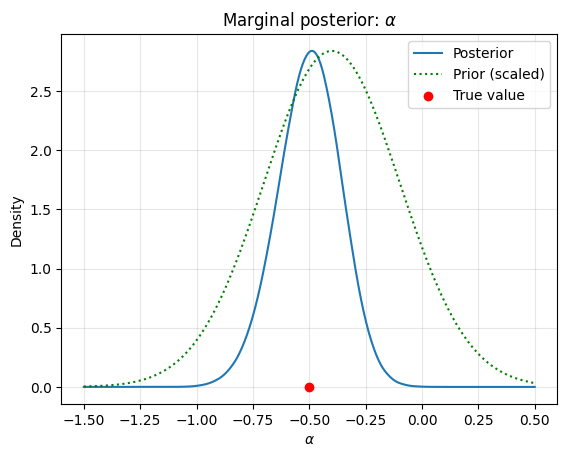

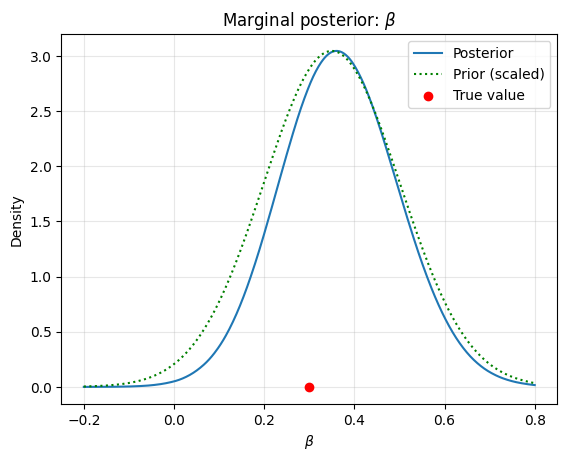

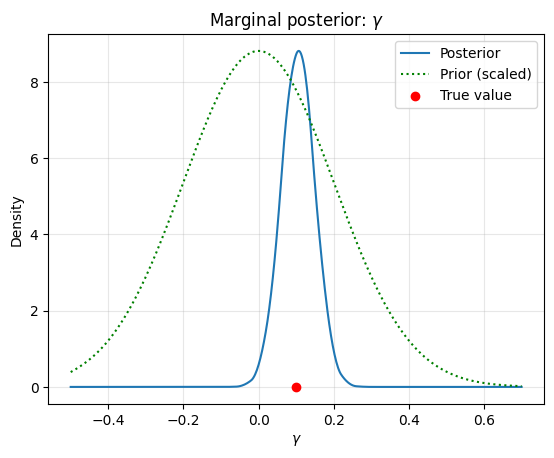

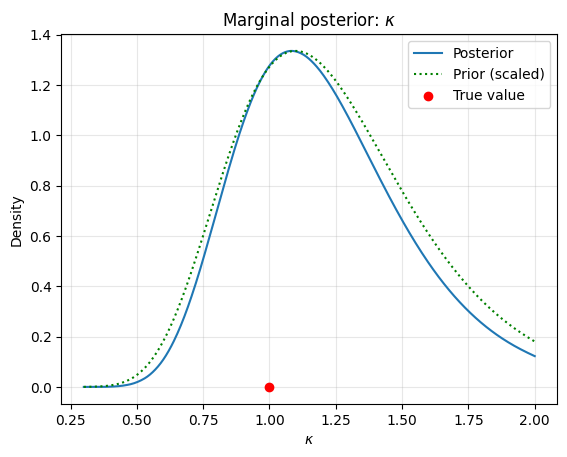

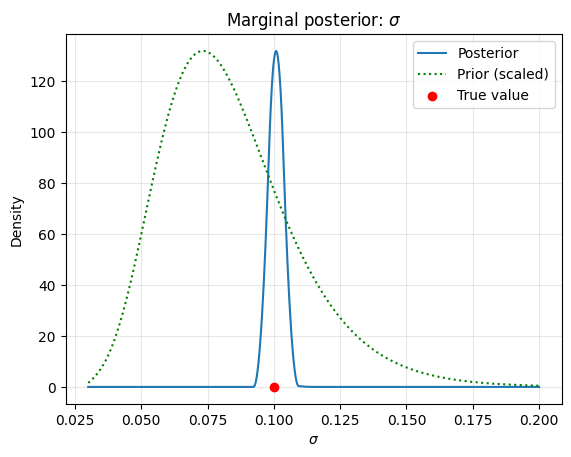

In [12]:

param_names = [r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\kappa$', r'$\sigma$']

for idx in range(5):
    plt.figure()
    # Marginalize over all dimensions except idx
    other_dims = [i for i in range(5) if i != idx]
    other_ws = torchtt.rank1TT([integration_weights[i] for i in other_dims])
    xplot = torch.linspace(bases[idx].interval[0], bases[idx].interval[1], 512)
    B = bases[idx](xplot)
    po = B.t() @ torchtt.dot(post, other_ws, other_dims).full()
    pr = B.t() @ torchtt.dot(prior, other_ws, other_dims).full()
    plt.plot(xplot.numpy(), po.numpy(), label='Posterior')
    plt.plot(xplot.numpy(), (pr/pr.max()*po.max()).numpy(), 'g:', label='Prior (scaled)')
    plt.scatter([params[idx]], [0], color='r', zorder=5, label='True value')
    plt.xlabel(param_names[idx])
    plt.ylabel('Density')
    plt.title(f'Marginal posterior: {param_names[idx]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.show()
